
 ANALYSIS FOR TROUBLED PROPERTIES
            City Zip Code  Longitude   Latitude  Inspection Frequency  \
0    Takoma Park    20912 -76.996454  38.987941                   1.0   
1    Takoma Park    20912 -77.000573  38.990459                   3.0   
2  Silver Spring    20904 -76.940884  39.077518                   1.0   
3    Takoma Park    20912 -77.000471  38.992002                   1.0   
4   Gaithersburg    20877 -77.205009  39.136578                   1.0   
5    Chevy Chase    20815 -77.093795  38.978623                   1.0   
6    Takoma Park    20912 -77.000616  38.993798                   3.0   
7    TAKOMA PARK    20912   0.000000   0.000000                   1.0   
8    Takoma Park    20912 -76.996619  38.987763                   2.0   
9    Takoma Park    20912 -77.000799  38.991557                   3.0   

   Compliant  Unit Count  Units Inspected  Average Violations Per Unit  \
0          0           6               12                         0.50   
1          0 

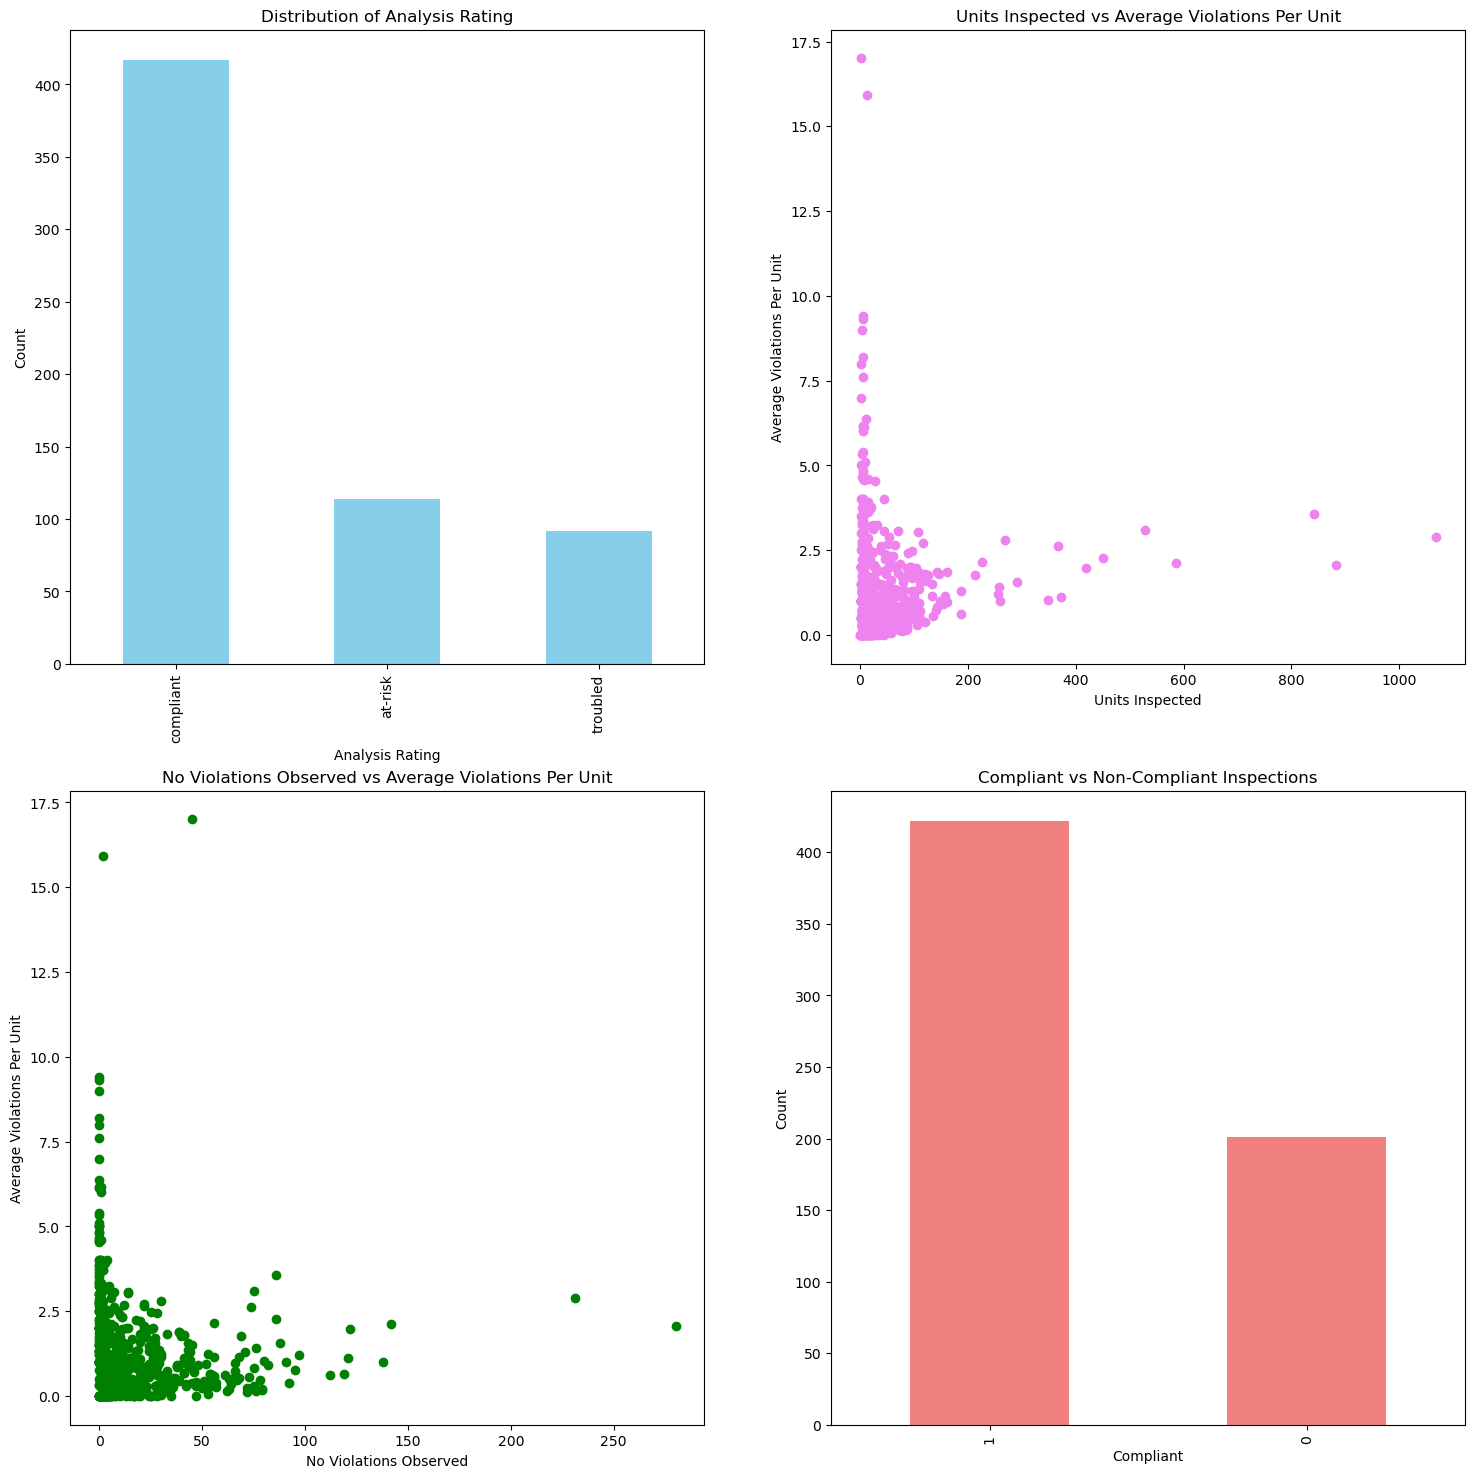

<Figure size 800x600 with 0 Axes>

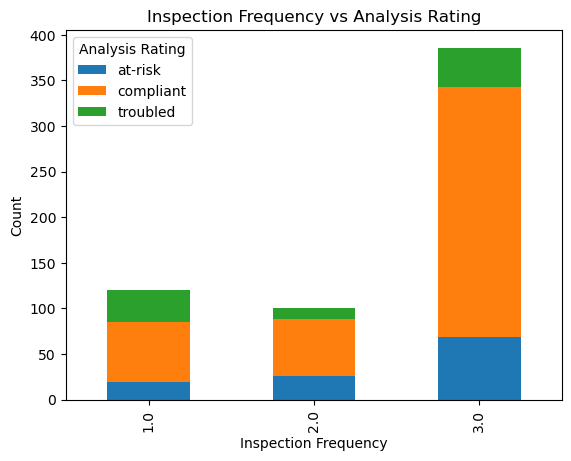


 DATA ENCODING
             City Zip Code  Longitude   Latitude  Inspection Frequency  \
0     Takoma Park    20912 -76.996454  38.987941                   1.0   
1     Takoma Park    20912 -77.000573  38.990459                   3.0   
2   Silver Spring    20904 -76.940884  39.077518                   1.0   
3     Takoma Park    20912 -77.000471  38.992002                   1.0   
4    Gaithersburg    20877 -77.205009  39.136578                   1.0   
5     Chevy Chase    20815 -77.093795  38.978623                   1.0   
6     Takoma Park    20912 -77.000616  38.993798                   3.0   
7     TAKOMA PARK    20912   0.000000   0.000000                   1.0   
9     Takoma Park    20912 -77.000799  38.991557                   3.0   
10  Silver Spring    20902 -77.048284  39.043349                   2.0   

    Compliant  Unit Count  Units Inspected  Average Violations Per Unit  \
0           0           6               12                         0.50   
1           0      

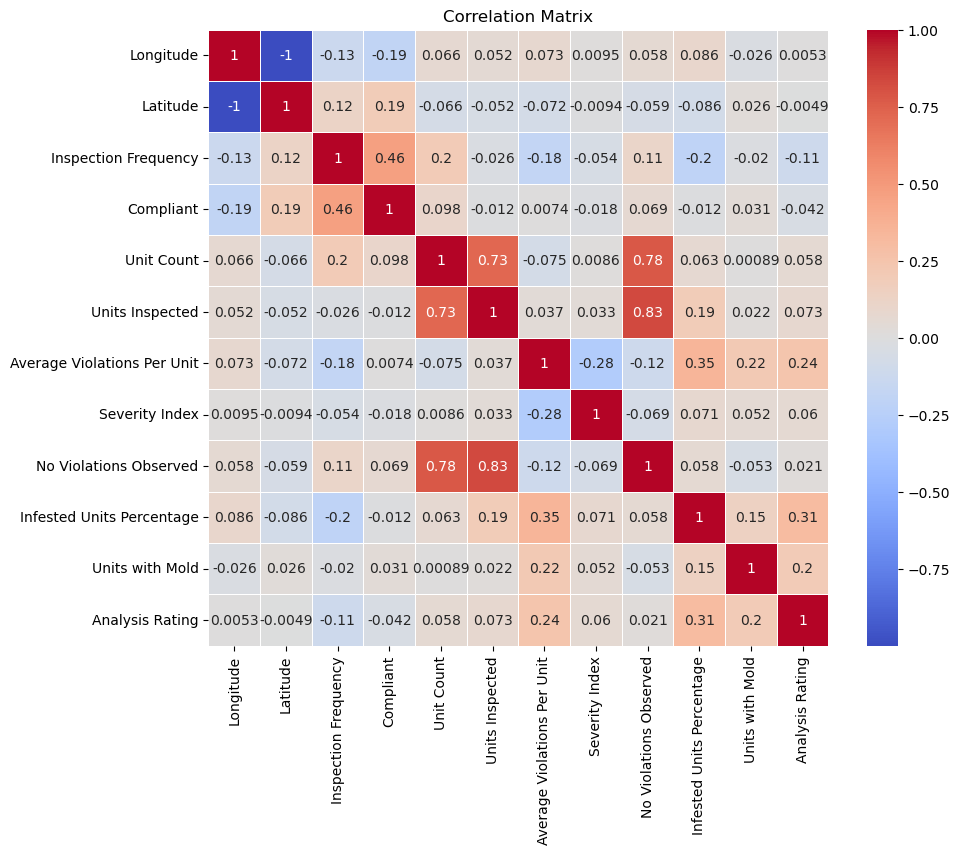


 Training Data Size:  (498, 8)

 Testing Data Size:  (125, 8)

 PERFORMANCE EVALUATION


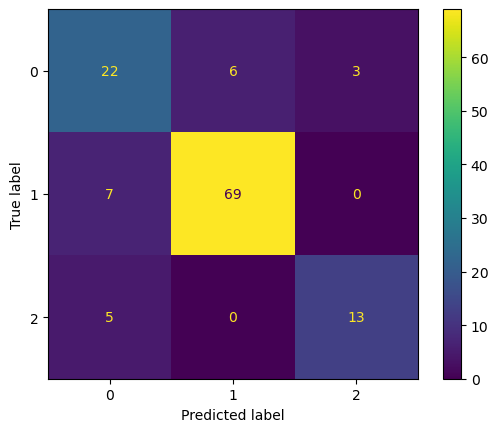


 Accuracy Score:  0.832

 Classification Report: 
               precision    recall  f1-score   support

           0       0.65      0.71      0.68        31
           1       0.92      0.91      0.91        76
           2       0.81      0.72      0.76        18

    accuracy                           0.83       125
   macro avg       0.79      0.78      0.79       125
weighted avg       0.84      0.83      0.83       125



In [ ]:
"""
Created Feb 23, 2024

@author: Gideon Assafuah

Decision Tree to predict real estate prices
"""

#Load necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split 
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

import warnings

#ignore warnings
warnings.filterwarnings("ignore")

#instantiate the label encoder
label_encoder = LabelEncoder()

#--------------------------class model--------------------------------------------------------

class DescisionTreeModel:
    
    def load_data(self, filepath):
        #Load the data from the file
        
        df = pd.read_csv(filepath)

        self.df = df
        # print the first 10 rows of the dataframe
        print(df.head(10))

        #print the shape of the dataframe
        print(df.shape)

    
    def clean_data(self):
        #Clean the data
        df = self.df

        #Check for missing values
        print("\n MISSING VALUES")
        print(df.isnull().sum())

        #Check for duplicate values
        print("\n DUPLICATE VALUES")
        print(df.duplicated().sum())

        #Drop duplicate values
        df = df.drop_duplicates()

        # replace missing values with the mean of the column
        df['Unit Count'] = df['Unit Count'].fillna(df['Unit Count'].mean())
        df['Average Violations Per Unit'] = df['Average Violations Per Unit'].fillna(df['Average Violations Per Unit'].mean())
        df['No Violations Observed'] = df['No Violations Observed'].fillna(df['No Violations Observed'].mean())
        df['Infested Units Percentage'] = df['Infested Units Percentage'].fillna(df['Infested Units Percentage'].mean())
        df['Units with Mold'] = df['Units with Mold'].fillna(df['Units with Mold'].mean())

        #remove rows with Analysis Rating column value of TBD  
        df = df[df['Analysis Rating'] != 'TBD']

        #Check for duplicate values
        print("\n DUPLICATE VALUES")
        print(df.duplicated().sum())

        #Check for missing values
        print("\n MISSING VALUES")
        print(df.isnull().sum())
        

        self.df = df

        # print the first 10 rows of the dataframe
        print(df.head(10))


    def visualize_data(self):
        #Visualize the data Before modeling
        print("\n VISUALIZING THE DATA BEFORE MODELING")

        df = self.df

        #Plot the data
        # plot the distribution of the target variable
        plt.figure(figsize=(18, 28))

        plt.subplot(3, 2, 1)
        df['Analysis Rating'].value_counts().plot(kind='bar', color='skyblue')
        plt.title('Distribution of Analysis Rating')
        plt.xlabel('Analysis Rating')
        plt.ylabel('Count')

        # scatter plot of united inspected vs average violations per unit
        plt.subplot(3, 2, 2)
        plt.scatter(df['Units Inspected'], df['Average Violations Per Unit'], color='violet')
        plt.title('Units Inspected vs Average Violations Per Unit')
        plt.xlabel('Units Inspected')
        plt.ylabel('Average Violations Per Unit')

        # scatter plot of No Violations Observed vs average rating per unit
        plt.subplot(3, 2, 3)
        plt.scatter(df['No Violations Observed'], df['Average Violations Per Unit'], color='green')
        plt.title('No Violations Observed vs Average Violations Per Unit')
        plt.xlabel('No Violations Observed')
        plt.ylabel('Average Violations Per Unit')

        # bar chart of compliant vs non-compliant inspections
        plt.subplot(3, 2, 4)
        df['Compliant'].value_counts().plot(kind='bar', color='lightcoral')
        plt.title('Compliant vs Non-Compliant Inspections')
        plt.xlabel('Compliant')
        plt.ylabel('Count')
        plt.show()

        # bar chart of inspection frequency vs analysis rating
        plt.figure(figsize=(8, 6))
        df.groupby('Inspection Frequency')['Analysis Rating'].value_counts().unstack().plot(kind='bar', stacked=True)
        plt.title('Inspection Frequency vs Analysis Rating')
        plt.xlabel('Inspection Frequency')
        plt.ylabel('Count')
        plt.show()



    def preprocess_data(self):
        #Preprocess the data
        
        df = self.df
        
        print('\n DATA ENCODING')     
        
        #Encode the target variable
        df['Analysis Rating'] = label_encoder.fit_transform(df['Analysis Rating'])

        # print the first 10 rows of the dataframe
        print(df.head(10))

        # remove text columns
        df = df.drop(['City', 'Zip Code'], axis=1)
        # correlation matrix
        print("\n CORRELATION MATRIX")
        plt.figure(figsize=(10, 8))
        sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
        plt.title('Correlation Matrix')
        plt.show()
        
        #Split the data into features and label
        features = df[
            [
                'Inspection Frequency', 
                'Compliant', 
                'Unit Count', 
                'Units Inspected', 
                'Average Violations Per Unit', 
                'No Violations Observed', 
                'Infested Units Percentage', 
                'Units with Mold']
            ]
        label = df['Analysis Rating']

        #Split the data into training and testing set
        X_train, X_test, y_train, y_test = train_test_split(features, label, test_size=0.2, random_state=42)

        print("\n Training Data Size: ", X_train.shape)
        print("\n Testing Data Size: ", X_test.shape)

        self.df = df
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test


    def train_DescisionTreeModel(self):
        #Train the model
        X_train = self.X_train
        y_train = self.y_train
        X_test = self.X_test

        #Instantiate the model
        DTClass = DecisionTreeClassifier(criterion='entropy', random_state=0)

        #Fit the model
        DTClass.fit(X_train, y_train)

        self.pred_y = DTClass.predict(X_test)
        self.DTClass = DTClass

    def evalute_DescisionTreeModel(self):
        #Evaluate the model
        print("\n PERFORMANCE EVALUATION")
        DTClass = self.DTClass
        y_test = self.y_test
        pred_y = self.pred_y

        #Confusion Matrix
        cm = confusion_matrix(y_test, pred_y, labels=DTClass.classes_)
        #Visualize the confusion matrix
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=DTClass.classes_)
        disp.plot()
        plt.show()


        #Accuracy Score
        print("\n Accuracy Score: ", accuracy_score(y_test, pred_y))
        #Classification Report
        print("\n Classification Report: \n", classification_report(y_test, pred_y))
    
    def predict_new_instance(self, new_instance):                                                
        pred_instance_type = self.DTClass.predict(new_instance)
        new_prediction =  label_encoder.inverse_transform(pred_instance_type)
        print('\n Analysis rating = ', new_prediction) 



#--------------------------class driver--------------------------------------------------------

# Analysis for troubled properties

print("\n ANALYSIS FOR TROUBLED PROPERTIES")
        
handle = DescisionTreeModel()

filepath = "/home/jovyan/data/troubled-properties.csv"

handle.load_data(filepath)

handle.clean_data()

handle.visualize_data()

handle.preprocess_data()

handle.train_DescisionTreeModel()

handle.evalute_DescisionTreeModel()

# Deployment of the model for dataset 1
# new data
inspection_frequency = input("Enter the Inspection Frequency: ")
compliant = input("Enter the Compliant: ")
unit_count = input("Enter the Unit Count: ")
units_inspected = input("Enter the Units Inspected: ")
average_violations_per_unit = input("Enter the Average Violations Per Unit: ")
no_violations_observed = input("Enter the No Violations Observed: ")
infested_units_percentage = input("Enter the Infested Units Percentage: ")
units_with_mold = input("Enter the Units with Mold: ")

print("\n New instance features")
print("Inspection Frequency: ", inspection_frequency)
print("Compliant: ", compliant)
print("Unit Count: ", unit_count)
print("Units Inspected: ", units_inspected)
print("Average Violations Per Unit: ", average_violations_per_unit)
print("No Violations Observed: ", no_violations_observed)
print("Infested Units Percentage: ", infested_units_percentage)
print("Units with Mold: ", units_with_mold)


new_data = [[inspection_frequency, compliant, unit_count, units_inspected, average_violations_per_unit, no_violations_observed, infested_units_percentage, units_with_mold]]
handle.predict_new_instance(new_data)   